In [ ]:
# necessary imports
import os
import re
import random
import datetime
from datetime import timedelta

import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    auc,
    precision_recall_curve
)

import tensorflow as tf
from keras.utils import to_categorical

import data_preprocessing
import data_models

## Read data and assing age groups

In [ ]:
# Define schema override
schema = {
    "Age": pl.Utf8,
}

# Read CSV with schema
raw_data = pl.read_csv("Data/SDBII_5.csv", schema_overrides=schema)

raw_data = raw_data.with_columns(
    pl.col("ts").str.to_datetime()
)

raw_data_sorted = raw_data.sort(["PtID", "ts"])
raw_data_sorted = raw_data_sorted.unique(subset=["PtID", "ts"], keep="first")

In [ ]:
n_subjects = raw_data_sorted.select(pl.col("PtID").n_unique()).item()
print(n_subjects)

2499


In [ ]:
df_age = data_preprocessing.convert_age_strings(raw_data_sorted)
df_age = data_preprocessing.assign_age_group_from_string_ranges(df_age)

## extract subjects with more data as test subjects

In [5]:
counts = (
    df_age
    .group_by(["AgeGroup", "PtID"])
    .agg(pl.count("GlucoseCGM").alias("count"))
)

top5_per_age = (
    counts
    .sort(["AgeGroup", "count"], descending=[False, True])
    .with_columns(
        pl.col("count")
        .rank("dense", descending=True)
        .over("AgeGroup")
        .alias("rank")
    )
    .filter(pl.col("rank") <= 10)
)

print(top5_per_age)

shape: (40, 4)
┌──────────┬──────────────────────┬────────┬──────┐
│ AgeGroup ┆ PtID                 ┆ count  ┆ rank │
│ ---      ┆ ---                  ┆ ---    ┆ ---  │
│ i32      ┆ str                  ┆ u32    ┆ u32  │
╞══════════╪══════════════════════╪════════╪══════╡
│ 0        ┆ 73.0_PEDAP           ┆ 118667 ┆ 1    │
│ 0        ┆ 53.0_PEDAP           ┆ 110035 ┆ 2    │
│ 0        ┆ 38.0_PEDAP           ┆ 109002 ┆ 3    │
│ 0        ┆ 87.0_PEDAP           ┆ 108795 ┆ 4    │
│ 0        ┆ 28.0_SENCE           ┆ 108294 ┆ 5    │
│ …        ┆ …                    ┆ …      ┆ …    │
│ 3        ┆ 91.0_WISDM           ┆ 105035 ┆ 6    │
│ 3        ┆ 205.0_WISDM          ┆ 104679 ┆ 7    │
│ 3        ┆ 165.0_WISDM          ┆ 104096 ┆ 8    │
│ 3        ┆ LIB193307_T1DGranada ┆ 104042 ┆ 9    │
│ 3        ┆ 47.0_WISDM           ┆ 103645 ┆ 10   │
└──────────┴──────────────────────┴────────┴──────┘


In [6]:
top5_per_age["count"].sum()

7130422

In [ ]:
# Converts top5_per_age into dictionary {AgeGroup: [PtIDs]}
result_dict = (
    top5_per_age
    .group_by("AgeGroup")
    .agg(pl.col("PtID").alias("PtIDs"))
    .to_dict(as_series=False)
)


age_to_ids = dict(zip(result_dict["AgeGroup"], result_dict["PtIDs"]))

In [8]:
subjects = list(age_to_ids.values())
subjects = np.array(subjects)

In [9]:
children = df_age.filter(pl.col("PtID").is_in(subjects[0]) & (pl.col("AgeGroup") ==0))
teenagers = df_age.filter(pl.col("PtID").is_in(subjects[1])& (pl.col("AgeGroup") ==1))
adults = df_age.filter(pl.col("PtID").is_in(subjects[2])& (pl.col("AgeGroup") ==2))
seniors = df_age.filter(pl.col("PtID").is_in(subjects[3])& (pl.col("AgeGroup") ==3))

df_filtered_age = df_age.filter(~(pl.col("PtID").is_in(subjects[0])))
df_filtered_age = df_filtered_age.filter(~(pl.col("PtID").is_in(subjects[1])))
df_filtered_age = df_filtered_age.filter(~(pl.col("PtID").is_in(subjects[2])))
df_filtered_age = df_filtered_age.filter(~(pl.col("PtID").is_in(subjects[3])))

In [10]:
n_subjects_before = df_age.select(pl.col("PtID").n_unique()).item()
print(n_subjects_before)

2499


In [11]:
subjects_by_age_before = (
    df_age.group_by("AgeGroup")
      .agg(pl.col("PtID").n_unique().alias("n_subjects"))
)
print(subjects_by_age_before)

shape: (4, 2)
┌──────────┬────────────┐
│ AgeGroup ┆ n_subjects │
│ ---      ┆ ---        │
│ i32      ┆ u32        │
╞══════════╪════════════╡
│ 0        ┆ 380        │
│ 3        ┆ 1035       │
│ 1        ┆ 407        │
│ 2        ┆ 766        │
└──────────┴────────────┘


In [12]:
n_subjects = df_filtered_age.select(pl.col("PtID").n_unique()).item()
print(n_subjects)

2459


In [13]:
subjects_by_age = (
    df_filtered_age.group_by("AgeGroup")
      .agg(pl.col("PtID").n_unique().alias("n_subjects"))
)
print(subjects_by_age)

shape: (4, 2)
┌──────────┬────────────┐
│ AgeGroup ┆ n_subjects │
│ ---      ┆ ---        │
│ i32      ┆ u32        │
╞══════════╪════════════╡
│ 0        ┆ 370        │
│ 3        ┆ 1025       │
│ 1        ┆ 395        │
│ 2        ┆ 754        │
└──────────┴────────────┘


In [14]:
avg_per_age = (
    df_filtered_age.group_by(["AgeGroup", "PtID"])
      .agg(pl.count("GlucoseCGM").alias("n_datapoints"))
      .group_by("AgeGroup")
      .agg(pl.col("n_datapoints").mean().alias("avg_CGM_points_per_age_group"))
)

print(avg_per_age)

shape: (4, 2)
┌──────────┬──────────────────────────────┐
│ AgeGroup ┆ avg_CGM_points_per_age_group │
│ ---      ┆ ---                          │
│ i32      ┆ f64                          │
╞══════════╪══════════════════════════════╡
│ 2        ┆ 42075.916446                 │
│ 3        ┆ 31605.37561                  │
│ 0        ┆ 50681.281081                 │
│ 1        ┆ 39418.772152                 │
└──────────┴──────────────────────────────┘


In [15]:
avg_per_age_filt = (
    df_age.group_by(["AgeGroup", "PtID"])
      .agg(pl.count("GlucoseCGM").alias("n_datapoints"))
      .group_by("AgeGroup")
      .agg(pl.col("n_datapoints").mean().alias("avg_CGM_points_per_age_group"))
)

print(avg_per_age_filt)

shape: (4, 2)
┌──────────┬──────────────────────────────┐
│ AgeGroup ┆ avg_CGM_points_per_age_group │
│ ---      ┆ ---                          │
│ i32      ┆ f64                          │
╞══════════╪══════════════════════════════╡
│ 2        ┆ 46433.82376                  │
│ 1        ┆ 41241.535627                 │
│ 3        ┆ 32352.592271                 │
│ 0        ┆ 52203.971053                 │
└──────────┴──────────────────────────────┘


In [ ]:

result = (
    df_age.group_by("AgeGroup")
      .agg(pl.count("GlucoseCGM").alias("total_count"))
)

print(result)

shape: (4, 2)
┌──────────┬─────────────┐
│ AgeGroup ┆ total_count │
│ ---      ┆ ---         │
│ i32      ┆ u32         │
╞══════════╪═════════════╡
│ 3        ┆ 33484933    │
│ 0        ┆ 19837509    │
│ 1        ┆ 16785305    │
│ 2        ┆ 35568309    │
└──────────┴─────────────┘


In [ ]:

result = (
    df_filtered_age.group_by("AgeGroup")
      .agg(pl.count("GlucoseCGM").alias("total_count"))
)

print(result)

shape: (4, 2)
┌──────────┬─────────────┐
│ AgeGroup ┆ total_count │
│ ---      ┆ ---         │
│ i32      ┆ u32         │
╞══════════╪═════════════╡
│ 0        ┆ 18752074    │
│ 3        ┆ 32395510    │
│ 1        ┆ 15570415    │
│ 2        ┆ 31725241    │
└──────────┴─────────────┘


In [ ]:

count = raw_data_sorted.select([
    pl.col(c).is_not_null().sum().alias(c)
    for c in raw_data_sorted.columns
])
count

ts,PtID,GlucoseCGM,Age,Sex,Database
u32,u32,u32,u32,u32,u32
237842393,237842393,105676056,237842393,237842393,237842393


In [ ]:

count = raw_data_sorted.select(
    pl.col("GlucoseCGM").filter(pl.col("GlucoseCGM") < 71).count()
).item()
count

4032032

In [ ]:

df_clean = (
    df_age  
    .drop_nulls()                            
)

records_per_person = df_clean.group_by("PtID").len().rename({"len": "num_records"})

# Computes days per person (num_records / 288)
days_per_person = records_per_person.with_columns(
    (pl.col("num_records") / 288).alias("days_of_data")
)

# Computes average across all persons
avg_days = days_per_person.select(pl.col("days_of_data").mean()).item()

print(days_per_person)
print(f"\nAverage days of data per person: {avg_days:.2f}")
print(f"\nmin days of data per person: {days_per_person.min()}")
print(f"\nmean days of data per person: {days_per_person.mean()}")
print(f"\nmax days of data per person: {days_per_person.max()}")

shape: (2_499, 3)
┌──────────────────────┬─────────────┬──────────────┐
│ PtID                 ┆ num_records ┆ days_of_data │
│ ---                  ┆ ---         ┆ ---          │
│ str                  ┆ u32         ┆ f64          │
╞══════════════════════╪═════════════╪══════════════╡
│ LIB193974_T1DGranada ┆ 21214       ┆ 73.659722    │
│ 66.0_SENCE           ┆ 100196      ┆ 347.902778   │
│ 81.0_SHD             ┆ 3333        ┆ 11.572917    │
│ LIB194041_T1DGranada ┆ 81299       ┆ 282.288194   │
│ Subject48_DiaTrend   ┆ 11808       ┆ 41.0         │
│ …                    ┆ …           ┆ …            │
│ 5.0_DLCP3            ┆ 58016       ┆ 201.444444   │
│ 211.0_RT-CGM         ┆ 8676        ┆ 30.125       │
│ 395.0_RT-CGM         ┆ 10708       ┆ 37.180556    │
│ LIB193606_T1DGranada ┆ 12731       ┆ 44.204861    │
│ 46.0_SENCE           ┆ 84210       ┆ 292.395833   │
└──────────────────────┴─────────────┴──────────────┘

Average days of data per person: 146.83

min days of data per p

In [ ]:
df_clean = df_age.drop_nulls()

 
days_per_person = (
    df_clean
    .group_by(["AgeGroup", "PtID"])
    .len()
    .rename({"len": "num_records"})
    .with_columns((pl.col("num_records") / 288).alias("days_of_data"))
)

print(days_per_person)

 
summary = (
    days_per_person
    .group_by("AgeGroup")
    .agg([
        pl.col("PtID").n_unique().alias("n_patients"),
        pl.col("days_of_data").mean().alias("avg_days"),
        pl.col("days_of_data").min().alias("min_days"),
        pl.col("days_of_data").median().alias("median_days"),
        pl.col("days_of_data").max().alias("max_days"),
    ])
    .sort("AgeGroup")
)

print("\nSummary per age group:")
print(summary)


shape: (2_588, 4)
┌──────────┬──────────────────────┬─────────────┬──────────────┐
│ AgeGroup ┆ PtID                 ┆ num_records ┆ days_of_data │
│ ---      ┆ ---                  ┆ ---         ┆ ---          │
│ i32      ┆ str                  ┆ u32         ┆ f64          │
╞══════════╪══════════════════════╪═════════════╪══════════════╡
│ 3        ┆ LIB193459_T1DGranada ┆ 10650       ┆ 36.979167    │
│ 3        ┆ 114.0_SHD            ┆ 3126        ┆ 10.854167    │
│ 3        ┆ LIB193304_T1DGranada ┆ 59621       ┆ 207.017361   │
│ 3        ┆ 46.0_SHD             ┆ 2082        ┆ 7.229167     │
│ 3        ┆ 130.0_SHD            ┆ 3232        ┆ 11.222222    │
│ …        ┆ …                    ┆ …           ┆ …            │
│ 3        ┆ 149.0_RT-CGM         ┆ 47823       ┆ 166.052083   │
│ 0        ┆ 93.0_PEDAP           ┆ 85807       ┆ 297.940972   │
│ 3        ┆ 41.0_RT-CGM          ┆ 90474       ┆ 314.145833   │
│ 2        ┆ 83.0_CITY            ┆ 50712       ┆ 176.083333   │
│ 2    

## Preprocessing

In [ ]:
# removes outliers 
cleaned_static = data_preprocessing.remove_outliers_polars(df_filtered_age, value="GlucoseCGM")

data_cleanedpd = cleaned_static.to_pandas()
# data should be sorted before applying imputation methods
data_cleanedpd = data_cleanedpd.sort_values(by=["PtID", "ts"]).reset_index(drop=True)

# linear interpolation is used for gaps which are less than 30 minute (6 consecuitve datapoints)
data_cleanedpd["GlucoseCGM"] = data_cleanedpd.groupby("PtID")["GlucoseCGM"].transform(
    lambda x: data_preprocessing.gap_limited_interpolation(x, limit=6)
)

# stineman interpolation for values between 30 adn 120 minutes
df_interpolated_stine = data_cleanedpd.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.interpolate_stineman_group(x, timestamp = "ts", value = "GlucoseCGM", llimit=6, ulimit=24))
df_interpolated_stine = df_interpolated_stine.sort_index()

df_interpolated_stine = df_interpolated_stine[["ts", "GlucoseCGM", "PtID",	"AgeGroup"]]

## class assgnment

In [ ]:
classes_df = df_interpolated_stine.sort_values(by=["PtID", "ts"]).reset_index(drop=True)
                                                          
# initially all classes are assigned a class -1
classes_df["Class0"] = -1

# hypoglycemic values are defined as class 0 with values equal and lower than 70 mg/dL
classes_df.loc[classes_df["GlucoseCGM"] <= 70, "Class0"] = 0

# calls the function class_generation to assing classes based on wanted intervals before hypogylcemia for each subject separately
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 5, 15, 1, col_name = "Class0")) # 5-15 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 15, 30, 2, col_name = "Class0")) # 15-30 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 30, 60, 3, col_name = "Class0"))  # 30-60 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts",  60, 125, 4, col_name = "Class0")) # 1-2 h
classes_df.loc[classes_df["Class0"] == -1, "Class0"] = 5

# sorts the glucose values by patient id and timestamps
df_sorted = classes_df.sort_values(by=["PtID", "ts"])
# reindexes based on the sorted dataset
df_sorted = df_sorted.reset_index(drop=True)
# value counts per class
df_sorted["Class0"].value_counts()

Class0
5    209063256
4      6102323
0      5932994
3      3101798
2      1664620
1      1176954
Name: count, dtype: int64

In [ ]:

classes_df = df_interpolated_stine.sort_values(by=["PtID", "ts"]).reset_index(drop=True)
                                                    
# initially all classes are assigned a class -1
classes_df["Class1"] = -1

# hypoglycemic values are defined as class 0 with values equal and lower than 70 mg/dL
classes_df.loc[classes_df["GlucoseCGM"] <= 70, "Class1"] = 0

# calls the function class_generation to assing classes based on wanted intervals before hypogylcemia for each subject separately
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 5, 20, 1, col_name = "Class1")) # 5-15 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 20, 50, 2, col_name = "Class1")) # 15-30 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 50, 125, 3, col_name = "Class1"))  # 30-60 min
classes_df.loc[classes_df["Class1"] == -1, "Class1"] = 4

# sorts the glucose values by patient id and timestamps
df_sorted1 = classes_df.sort_values(by=["PtID", "ts"])
# reindexes based on the sorted dataset
df_sorted1 = df_sorted1.reset_index(drop=True)

print(df_sorted1["Class1"].value_counts())


Class1
4    209063256
3      7108303
0      5932994
2      3195689
1      1741703
Name: count, dtype: int64


In [ ]:
classes_df = df_interpolated_stine.sort_values(by=["PtID", "ts"]).reset_index(drop=True)
classes_df["Class2"] = -1
# hypoglycemic values are defined as class 0 with values equal and lower than 70 mg/dL
classes_df.loc[classes_df["GlucoseCGM"] <= 70, "Class2"] = 0

# calls the function class_generation to assing classes based on wanted intervals before hypogylcemia for each subject separately
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 5, 25, 1, col_name = "Class2")) # 5-15 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 25, 65, 2, col_name = "Class2")) # 15-30 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 65, 125, 3, col_name = "Class2"))  # 30-60 min
classes_df.loc[classes_df["Class2"] == -1, "Class2"] = 4

# sorts the glucose values by patient id and timestamps
df_sorted2 = classes_df.sort_values(by=["PtID", "ts"])
# reindexes based on the sorted dataset
df_sorted2 = df_sorted2.reset_index(drop=True)

df_sorted2["Class2"].value_counts()

Class2
4    209063256
0      5932994
3      5608033
2      4141415
1      2296247
Name: count, dtype: int64

## features

In [ ]:
# here adjust df_sorted to df_sorted1 or df_sorted2 for training different class binnings
print(df_sorted["GlucoseCGM"].min())
print(df_sorted["GlucoseCGM"].max())
df_sorted = df_sorted.sort_values(by=["PtID", "ts"]).reset_index(drop=True)

df_scaled = data_preprocessing.normalize_data(df_sorted, "GlucoseCGM")
print(df_scaled["PtID"].nunique())

40.0
500.0
2459


## extract for ablation

In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)

import pandas as pd
from sklearn.model_selection import train_test_split

id_col = "PtID"

# extracts unique PtIDs
ptids = df_scaled[id_col].dropna().unique()

# splits IDs into train/test  
train_ids, test_ids = train_test_split(
    ptids,
    test_size=0.9,
    random_state=42,
    shuffle=True
)

# plits the actual dataframe by those IDs
train_df = df_scaled[df_scaled[id_col].isin(train_ids)].copy()
test_df  = df_scaled[df_scaled[id_col].isin(test_ids)].copy()

assert set(train_df[id_col].unique()).isdisjoint(set(test_df[id_col].unique()))
print(len(train_ids), len(test_ids), train_df.shape, test_df.shape)
df_scaled = {age: group for age, group in train_df.groupby("AgeGroup")}

## Ablation Studies

In [ ]:
from sklearn.model_selection import train_test_split
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)

def data_initialization(results, convert_to_shape = 9, seed= 42):

    X_data_train = []
    Y_data_train = []
    all_subjects_X = []
    all_subjects_Y = []

    for age, (X_data, Y_data) in results.items():
        print(f"Splitting data for age group {age}...")

        X_data_train.append(X_data) 
        Y_data_train.append(Y_data)

    for group in X_data_train:        # each age group
        for subjects in group:    # list of subjects in that group
            for subj in subjects:
                subj_concat = np.concatenate(subj, axis=0)
                flattened_data = subj_concat.reshape(-1,convert_to_shape,1)
                all_subjects_X.append(flattened_data)

    print(f"Total subjects: {len(all_subjects_X)}")
    print(f"Shape of first subject data: {all_subjects_X[0].shape}")



    for group in Y_data_train:        # each age group
        for subjects in group:    # list of subjects in that group
            for subj in subjects:
                subj_concat = np.concatenate(subj, axis=0)
                all_subjects_Y.append(subj_concat)

    print(f"Total subjects: {len(all_subjects_Y)}")
    print(f"Shape of first subject data: {all_subjects_Y[0].shape}")


    idx = np.arange(0, len(all_subjects_X))
    train_idx, test_idx = train_test_split(idx, test_size=0.3, shuffle=True, random_state=seed)

    # extracts the selected subjects for training for the X and Y folds
    X_train_fold = [all_subjects_X[i] for i in train_idx]
    Y_train_fold = [all_subjects_Y[i] for i in train_idx]
    # extracts the selected subjects for testing for the X and Y folds
    X_test_fold = [all_subjects_X[i] for i in test_idx]
    Y_test_fold = [all_subjects_Y[i] for i in test_idx]

    # flattens the arrays of single subjects into one array of shape (X,25,2)
    X_train_fold = np.concatenate(X_train_fold, axis=0)
    Y_train_fold = np.concatenate(Y_train_fold, axis=0)
    X_test_fold = np.concatenate(X_test_fold, axis=0)
    Y_test_fold= np.concatenate(Y_test_fold, axis=0)

    return X_train_fold, Y_train_fold, X_test_fold, Y_test_fold 

In [ ]:
def extract_valid_windows_GLC(
    df_org: pd.DataFrame,
    timestamp_col: str = "ts",
    feature_col: str = "GlucoseCGM",
    class_col: str = "Class",
    expected_sample_count: int = 25,
    min_window_duration = np.timedelta64(2, "h")
):
    """
    This function is used genearte time series data and splits the data into train, validation, and test data.
    Parameters:
   - df_org is the original pandas dataframe, 
   - timestamp_col is the name of the column with the timestamps, 
   - feature_col is the name of the column which should be returned as a time series,
   - class_col is name of the column with the classes,
   - expected_sample_count is the number of allowed continuous values in a time series,
    - min_window_duration is the allowed continuous time of a time series
    Output: It returns a list including six separate list for X_train, X_val, X_test, Y_train, Y_val, and Y_test
   """ 
    # X_train, and Y_train are initialized as empty arrays
    X_train = []
    Y_train = []

    # converts pandas DataFrame to polars for faster execution
    df = pl.from_pandas(df_org)
    # sorts by timestamp to ensure chronological order
    df = df.sort(timestamp_col)

    # extracts timestamps and total row count
    timestamps = df[timestamp_col].to_numpy()
    n_rows = df.height

    # initializes empty lists for feature windows and labels
    windows = []
    labels = []

    # sets starting index for window generation
    start_idx = 0

    # iterates over all rows to construct valid windows
    for end_idx in range(n_rows):
        # moves start index if window exceeds allowed duration
        while timestamps[end_idx] - timestamps[start_idx] > min_window_duration:
            start_idx += 1

        # calculates number of samples in current window
        count = end_idx - start_idx + 1

        # checks if window meets required duration and sample count
        if (
            timestamps[end_idx] - timestamps[start_idx] >= min_window_duration and
            count == expected_sample_count
        ):
            # extracts current time window
            window_df = df.slice(start_idx, count)

            # skips window if missing values are present
            nulls = window_df.null_count().row(0)
            if all(count == 0 for count in nulls):
                # retrieves label from last row in window
                label = window_df[class_col].to_list()[-1]
                # allows only classes 0–4
                if label in {0, 1, 2, 3, 4}:
                    # stores feature sequence and label
                    windows.append(window_df[feature_col].to_list())
                    labels.append(label)

    # checks if any valid windows were found
    if len(windows) > 0:
        # converts to numpy arrays
        windows = np.array(windows).reshape(-1, 1)
        labels = np.array(labels).reshape(-1, 1)

        # reshapes data for model input
        X_data = windows.reshape(-1, expected_sample_count, 1)
        Y_data = labels.reshape(-1, 1)

        # appends subject data to training sets
        X_train.append(X_data)
        Y_train.append(Y_data)

        # returns feature and label arrays
        return X_train, Y_train
    else:
        # returns nothing if no valid window exists
        return
    

    
def create_X_Y(df, feature= "PtID", labels = "Class", sample_count= 25, hours = 2, modus = "h"):

    # generates time series with sliding window approach
    result = df.groupby(feature).apply(lambda g: extract_valid_windows_GLC(g, class_col = labels, expected_sample_count = sample_count,
    min_window_duration = np.timedelta64(hours, modus)))

    # filters out None values of subjects with insufficient data
    filtered_result = [item for item in result if item is not None]
    # unpacks the values
    X_data, Y_data = zip(*filtered_result)

    return X_data, Y_data


## Class Set 0

2026-03-04 10:23:49.419694: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 10:23:49.420369: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 0...
Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)


2026-03-04 10:28:25.292678: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/14198 [..............................] - ETA: 58:26

2026-03-04 11:08:58.428558: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14198/14198 [==============================] - 37s 3ms/step


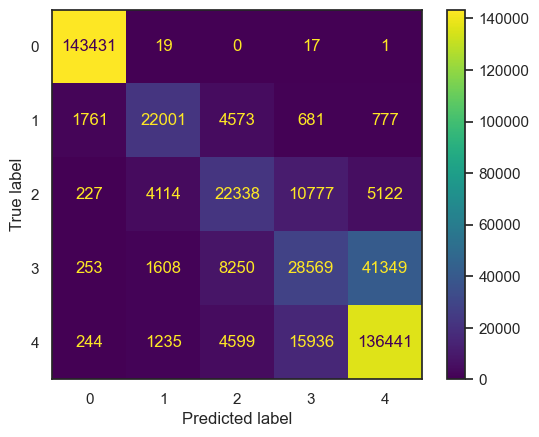

              precision    recall  f1-score   support

           0     0.9830    0.9997    0.9913    143468
           1     0.7593    0.7385    0.7487     29793
           2     0.5618    0.5246    0.5426     42578
           3     0.5103    0.3570    0.4201     80029
           4     0.7428    0.8611    0.7976    158455

    accuracy                         0.7765    454323
   macro avg     0.7114    0.6962    0.7001    454323
weighted avg     0.7618    0.7765    0.7651    454323

Class PR AUC: [[0.9999594877056861, 0.8323797473124639, 0.5614026440352704, 0.47353970563936454, 0.861567035838957]]
Mac PR AUC: ([0.7457697241063485])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)


2026-03-04 11:09:51.505057: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/15223 [..............................] - ETA: 1:00:31

2026-03-04 11:49:13.097396: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15223/15223 [==============================] - 41s 3ms/step


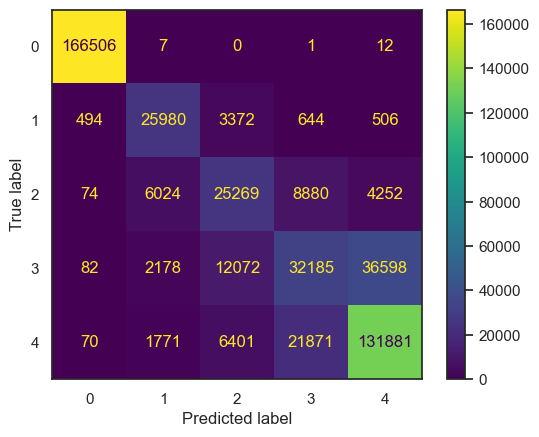

              precision    recall  f1-score   support

           0     0.9957    0.9999    0.9978    166526
           1     0.7225    0.8382    0.7760     30996
           2     0.5363    0.5679    0.5516     44499
           3     0.5062    0.3872    0.4388     83115
           4     0.7612    0.8141    0.7868    161994

    accuracy                         0.7838    487130
   macro avg     0.7044    0.7215    0.7102    487130
weighted avg     0.7749    0.7838    0.7774    487130

Class PR AUC: [[0.9999594877056861, 0.8323797473124639, 0.5614026440352704, 0.47353970563936454, 0.861567035838957], [0.9999937298545314, 0.8526330279547694, 0.5511471096314047, 0.44380302270114413, 0.8544538578276079]]
Mac PR AUC: ([0.7457697241063485, 0.7404061495938914])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first sub

2026-03-04 11:50:10.797411: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/15495 [..............................] - ETA: 1:04:18

2026-03-04 12:27:49.037781: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15495/15495 [==============================] - 40s 3ms/step


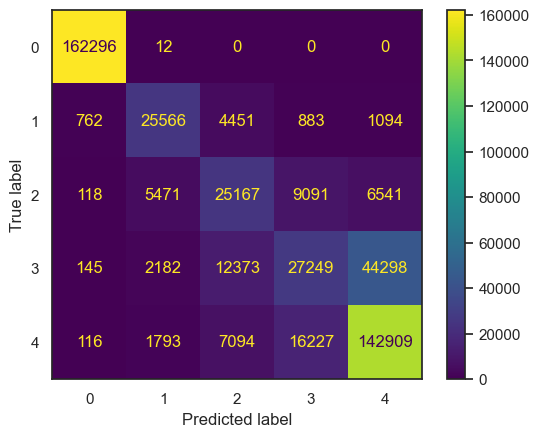

              precision    recall  f1-score   support

           0     0.9930    0.9999    0.9965    162308
           1     0.7300    0.7805    0.7544     32756
           2     0.5127    0.5425    0.5272     46388
           3     0.5098    0.3159    0.3901     86247
           4     0.7335    0.8499    0.7874    168139

    accuracy                         0.7728    495838
   macro avg     0.6958    0.6978    0.6911    495838
weighted avg     0.7586    0.7728    0.7602    495838

Class PR AUC: [[0.9999594877056861, 0.8323797473124639, 0.5614026440352704, 0.47353970563936454, 0.861567035838957], [0.9999937298545314, 0.8526330279547694, 0.5511471096314047, 0.44380302270114413, 0.8544538578276079], [0.9999927981208786, 0.8236760713196087, 0.5282419401694833, 0.45923370436990013, 0.8552157219690822]]
Mac PR AUC: ([0.7457697241063485, 0.7404061495938914, 0.7332720471897904])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = create_X_Y(group_df, feature="PtID", labels = "Class0", sample_count=7, hours=30, modus="m")
    results[age] = (X_data, Y_data)

for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 7, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    focloss = tf.keras.losses.CategoricalFocalCrossentropy()

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(5))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/Ablation_Class0_30min_default.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

2026-03-04 12:28:47.116500: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 12:28:47.116529: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)
Alpha weights: [0.40356728 2.0208597  1.4209031  0.76324093 0.39142853]


2026-03-04 12:28:49.702192: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 13:09:42.966284: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14198/14198 [==============================] - 37s 3ms/step


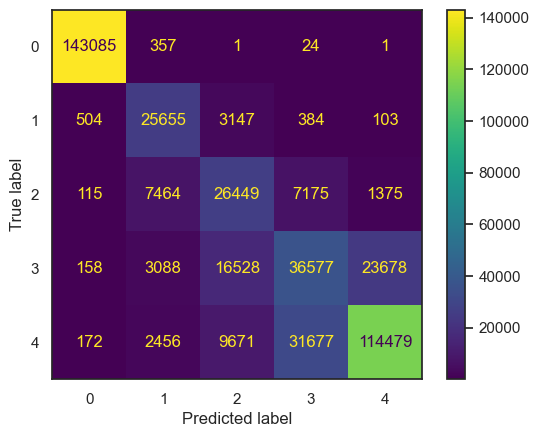

              precision    recall  f1-score   support

           0     0.9934    0.9973    0.9954    143468
           1     0.6575    0.8611    0.7456     29793
           2     0.4740    0.6212    0.5377     42578
           3     0.4823    0.4570    0.4693     80029
           4     0.8198    0.7225    0.7681    158455

    accuracy                         0.7621    454323
   macro avg     0.6854    0.7318    0.7032    454323
weighted avg     0.7721    0.7621    0.7642    454323

Class PR AUC: [[0.9999130964178279, 0.8391139660512239, 0.5484298930507178, 0.44874320630243425, 0.8590966125525435]]
Mac PR AUC: ([0.7390593548749494])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)
Alpha weights: [0.42033464 2.0135972  1.4184659  0.7601351  0.38746703]


2026-03-04 13:10:36.010717: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 13:51:13.396498: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15223/15223 [==============================] - 40s 3ms/step


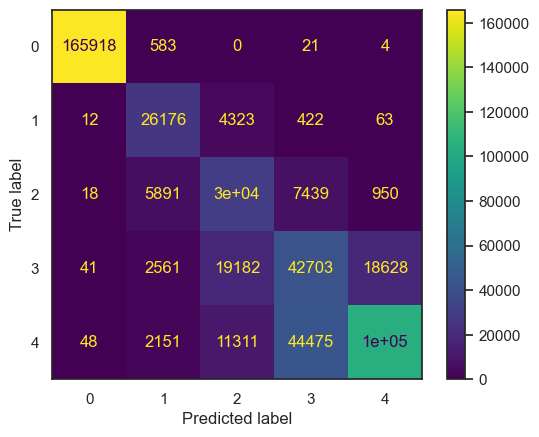

              precision    recall  f1-score   support

           0     0.9993    0.9963    0.9978    166526
           1     0.7006    0.8445    0.7659     30996
           2     0.4645    0.6787    0.5515     44499
           3     0.4492    0.5138    0.4793     83115
           4     0.8411    0.6421    0.7282    161994

    accuracy                         0.7575    487130
   macro avg     0.6909    0.7351    0.7046    487130
weighted avg     0.7850    0.7575    0.7642    487130

Class PR AUC: [[0.9999130964178279, 0.8391139660512239, 0.5484298930507178, 0.44874320630243425, 0.8590966125525435], [0.9999670092404307, 0.8475676381301889, 0.5568254413359988, 0.4277032876404386, 0.8530896777685988]]
Mac PR AUC: ([0.7390593548749494, 0.7370306108231313])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first sub

2026-03-04 13:52:10.289600: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 14:28:38.640572: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15495/15495 [==============================] - 40s 3ms/step


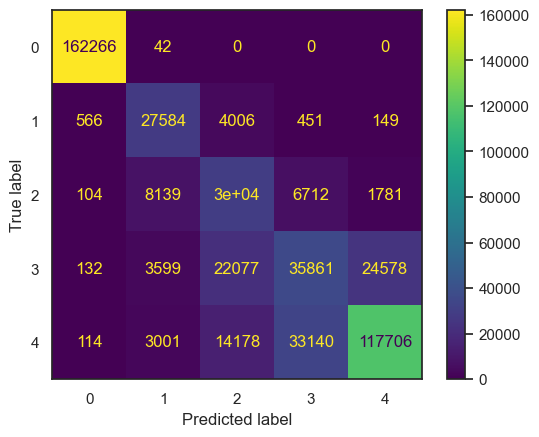

              precision    recall  f1-score   support

           0     0.9944    0.9997    0.9971    162308
           1     0.6511    0.8421    0.7344     32756
           2     0.4241    0.6392    0.5099     46388
           3     0.4708    0.4158    0.4416     86247
           4     0.8162    0.7001    0.7537    168139

    accuracy                         0.7524    495838
   macro avg     0.6713    0.7194    0.6873    495838
weighted avg     0.7669    0.7524    0.7550    495838

Class PR AUC: [[0.9999130964178279, 0.8391139660512239, 0.5484298930507178, 0.44874320630243425, 0.8590966125525435], [0.9999670092404307, 0.8475676381301889, 0.5568254413359988, 0.4277032876404386, 0.8530896777685988], [0.9999882736338346, 0.8176218946408431, 0.49823526764385917, 0.42876166197057247, 0.8537608894347049]]
Mac PR AUC: ([0.7390593548749494, 0.7370306108231313, 0.7196735974647628])


In [ ]:
## ohne klasse 4 mit weigths 
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 7, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=5).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(5))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/Ablation_Class0_30min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## Class Set 1

2026-03-03 22:10:00.142719: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-03-03 22:10:00.149321: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-03 22:10:00.149342: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-03-03 22:10:00.149453: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-03 22:10:00.149538: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 0...
Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)


2026-03-03 22:14:36.912242: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-03 22:14:36.912286: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Alpha weights: [0.5679258  1.9178873  1.0417908  0.47239587]


2026-03-03 22:14:37.881397: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/14198 [..............................] - ETA: 53:16

2026-03-03 22:50:36.344878: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14198/14198 [==============================] - 34s 2ms/step


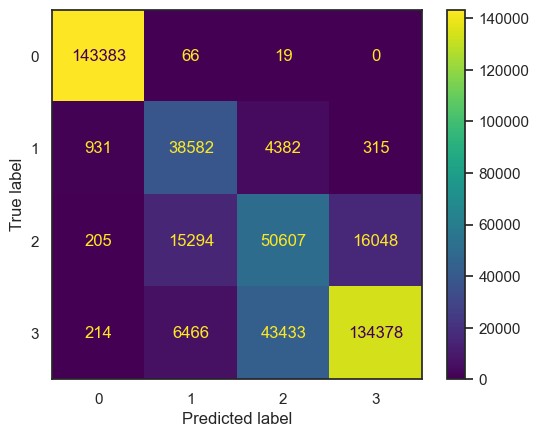

              precision    recall  f1-score   support

           0     0.9907    0.9994    0.9950    143468
           1     0.6387    0.8727    0.7376     44210
           2     0.5141    0.6160    0.5604     82154
           3     0.8914    0.7284    0.8017    184491

    accuracy                         0.8077    454323
   macro avg     0.7587    0.8041    0.7737    454323
weighted avg     0.8299    0.8077    0.8129    454323

Class PR AUC: [[0.9999507609658647, 0.8394426589416457, 0.5421668851541498, 0.9154453992699756]]
Mac PR AUC: ([0.824251426082909])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)
Alpha weights: [0.5899635  1.907225   1.0361248  0.46668643]


2026-03-03 22:51:24.416401: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/15223 [..............................] - ETA: 1:01:56

2026-03-03 23:26:39.888435: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15223/15223 [==============================] - 37s 2ms/step


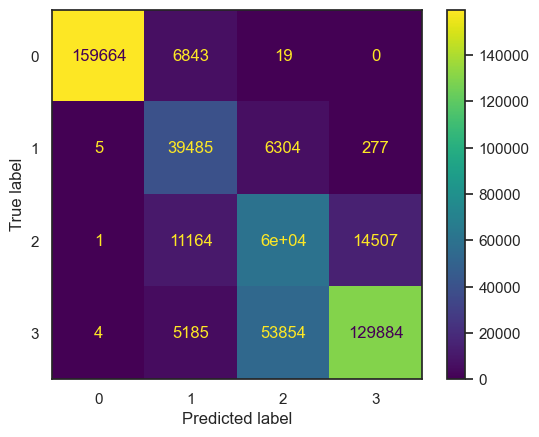

              precision    recall  f1-score   support

           0     0.9999    0.9588    0.9789    166526
           1     0.6300    0.8570    0.7262     46071
           2     0.4990    0.7001    0.5827     85606
           3     0.8978    0.6875    0.7787    188927

    accuracy                         0.7985    487130
   macro avg     0.7567    0.8009    0.7666    487130
weighted avg     0.8373    0.7985    0.8077    487130

Class PR AUC: [[0.9999507609658647, 0.8394426589416457, 0.5421668851541498, 0.9154453992699756], [0.9999837698822897, 0.7786583879340343, 0.5466351797419358, 0.9127749151009679]]
Mac PR AUC: ([0.824251426082909, 0.8095130631648069])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)
Alpha weights: [0.57506365 1.9204668  1.037458   0.46701178]


2026-03-03 23:27:32.786150: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/15495 [..............................] - ETA: 59:32

2026-03-04 00:02:55.662619: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15495/15495 [==============================] - 38s 2ms/step


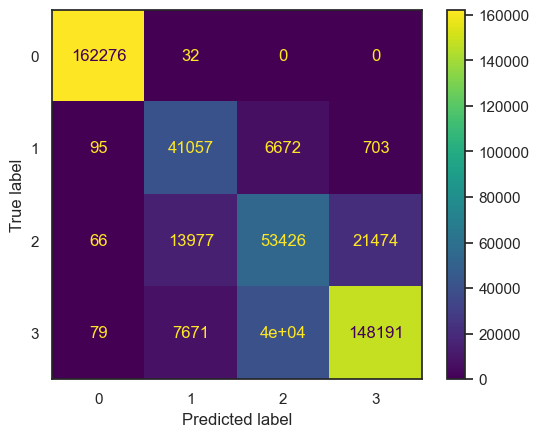

              precision    recall  f1-score   support

           0     0.9985    0.9998    0.9992    162308
           1     0.6544    0.8461    0.7380     48527
           2     0.5331    0.6007    0.5649     88943
           3     0.8698    0.7558    0.8088    196060

    accuracy                         0.8167    495838
   macro avg     0.7640    0.8006    0.7777    495838
weighted avg     0.8305    0.8167    0.8204    495838

Class PR AUC: [[0.9999507609658647, 0.8394426589416457, 0.5421668851541498, 0.9154453992699756], [0.9999837698822897, 0.7786583879340343, 0.5466351797419358, 0.9127749151009679], [0.9999921237126868, 0.8273310848573119, 0.5508622410021139, 0.9091775148531517]]
Mac PR AUC: ([0.824251426082909, 0.8095130631648069, 0.8218407411063161])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=7, hours=30, modus="m")
    results[age] = (X_data, Y_data)

for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 7, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/Ablation_Class1_30min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## 45 min

Processing age group 0...

2026-03-04 00:03:48.601185: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 00:03:48.601222: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8553, 10, 1)
Total subjects: 247
Shape of first subject data: (8553,)
Alpha weights: [0.5686081  1.9173095  1.0415387  0.47254324]


2026-03-04 00:08:22.795662: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/14143 [..............................] - ETA: 50:32

2026-03-04 00:45:38.757578: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14143/14143 [==============================] - 31s 2ms/step


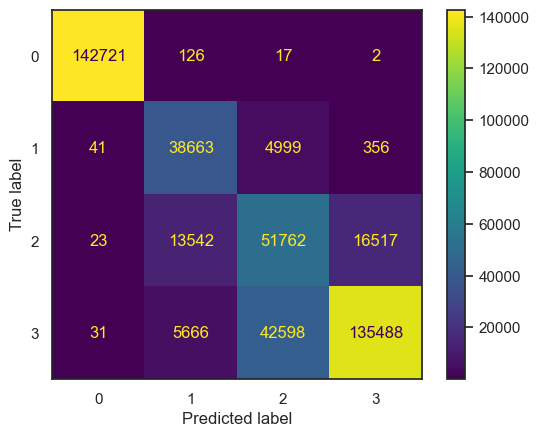

              precision    recall  f1-score   support

           0     0.9993    0.9990    0.9992    142866
           1     0.6666    0.8775    0.7577     44059
           2     0.5209    0.6324    0.5713     81844
           3     0.8892    0.7372    0.8061    183783

    accuracy                         0.8146    452552
   macro avg     0.7690    0.8115    0.7836    452552
weighted avg     0.8357    0.8146    0.8199    452552

Class PR AUC: [[0.9999869634258639, 0.8543662894514675, 0.5510649742991253, 0.9173887821675931]]
Mac PR AUC: ([0.8307017523360125])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8553, 10, 1)
Total subjects: 247
Shape of first subject data: (8553,)
Alpha weights: [0.59057045 1.9067366  1.0358241  0.4668689 ]


2026-03-04 00:46:24.684957: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/15152 [..............................] - ETA: 55:06

2026-03-04 01:23:05.339626: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15152/15152 [==============================] - 35s 2ms/step


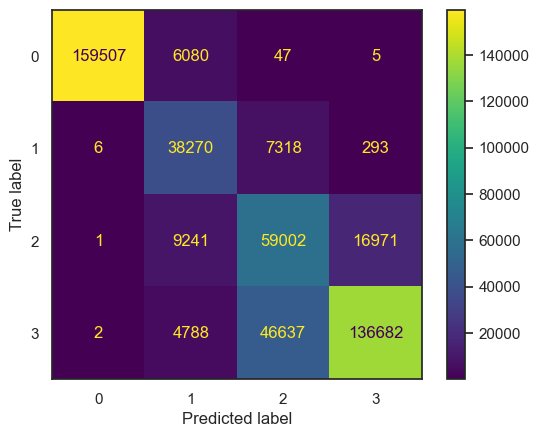

              precision    recall  f1-score   support

           0     0.9999    0.9630    0.9811    165639
           1     0.6555    0.8340    0.7341     45887
           2     0.5221    0.6924    0.5953     85215
           3     0.8878    0.7266    0.7992    188109

    accuracy                         0.8115    484850
   macro avg     0.7664    0.8040    0.7774    484850
weighted avg     0.8399    0.8115    0.8193    484850

Class PR AUC: [[0.9999869634258639, 0.8543662894514675, 0.5510649742991253, 0.9173887821675931], [0.9999915730731681, 0.8129630235280467, 0.5862484563182203, 0.9127838021018281]]
Mac PR AUC: ([0.8307017523360125, 0.8279967137553158])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8553, 10, 1)
Total subjects: 247
Shape of first subject data: (8553,)
Alpha weights: [0.5756491  1.9197044  1.0374817  0.46716473]


2026-03-04 01:23:56.738536: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/15426 [..............................] - ETA: 55:43

2026-03-04 02:00:54.843012: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15426/15426 [==============================] - 34s 2ms/step


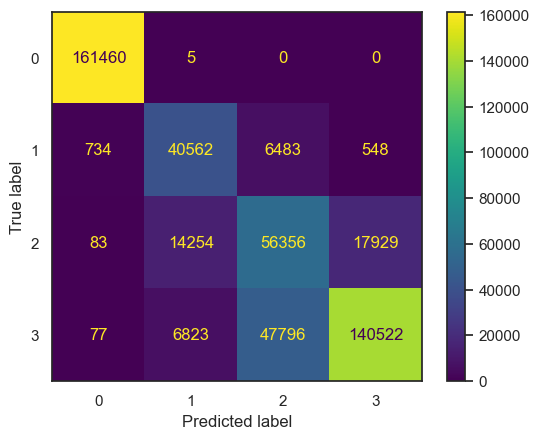

              precision    recall  f1-score   support

           0     0.9945    1.0000    0.9972    161465
           1     0.6580    0.8393    0.7377     48327
           2     0.5094    0.6359    0.5657     88622
           3     0.8838    0.7198    0.7934    195218

    accuracy                         0.8081    493632
   macro avg     0.7614    0.7988    0.7735    493632
weighted avg     0.8307    0.8081    0.8137    493632

Class PR AUC: [[0.9999869634258639, 0.8543662894514675, 0.5510649742991253, 0.9173887821675931], [0.9999915730731681, 0.8129630235280467, 0.5862484563182203, 0.9127838021018281], [0.9999960980069774, 0.8266585564315974, 0.5392457545092451, 0.9110464582589677]]
Mac PR AUC: ([0.8307017523360125, 0.8279967137553158, 0.819236716801697])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=10, hours=45, modus="m")
    results[age] = (X_data, Y_data)

for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 10, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/Ablation_Class1_45min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## 90 min

2026-03-04 02:01:46.196083: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 02:01:46.196116: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 0...
Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8453, 19, 1)
Total subjects: 247
Shape of first subject data: (8453,)
Alpha weights: [0.5690777  1.9158401  1.0422816  0.47280037]


2026-03-04 02:06:23.315602: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/13982 [..............................] - ETA: 51:06

2026-03-04 02:46:02.807779: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


13982/13982 [==============================] - 33s 2ms/step


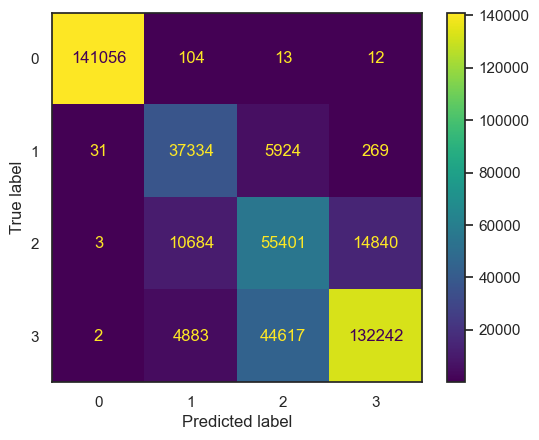

              precision    recall  f1-score   support

           0     0.9997    0.9991    0.9994    141185
           1     0.7043    0.8571    0.7733     43558
           2     0.5229    0.6846    0.5929     80928
           3     0.8974    0.7276    0.8036    181744

    accuracy                         0.8181    447415
   macro avg     0.7811    0.8171    0.7923    447415
weighted avg     0.8432    0.8181    0.8243    447415

Class PR AUC: [[0.9999924040176762, 0.8552988047612452, 0.5653236294064389, 0.920381924252643]]
Mac PR AUC: ([0.8352491906095008])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8453, 19, 1)
Total subjects: 247
Shape of first subject data: (8453,)
Alpha weights: [0.590931  1.9052479 1.036576  0.4672452]


2026-03-04 02:46:51.455020: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/14943 [..............................] - ETA: 53:06

2026-03-04 03:26:24.692158: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14943/14943 [==============================] - 37s 2ms/step


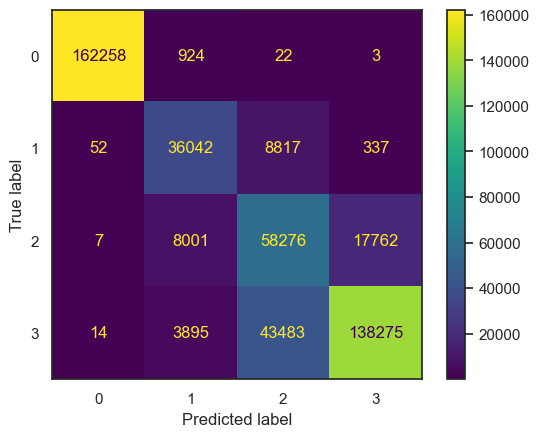

              precision    recall  f1-score   support

           0     0.9996    0.9942    0.9969    163207
           1     0.7376    0.7965    0.7660     45248
           2     0.5269    0.6934    0.5988     84046
           3     0.8842    0.7447    0.8085    185667

    accuracy                         0.8258    478168
   macro avg     0.7871    0.8072    0.7925    478168
weighted avg     0.8469    0.8258    0.8319    478168

Class PR AUC: [[0.9999924040176762, 0.8552988047612452, 0.5653236294064389, 0.920381924252643], [0.9999860742848039, 0.8407996338065276, 0.5828363511094832, 0.9157287520412931]]
Mac PR AUC: ([0.8352491906095008, 0.8348377028105269])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8453, 19, 1)
Total subjects: 247
Shape of first subject data: (8453,)
Alpha weights: [0.57602423 1.9187404  1.0378942  0.46734157]


2026-03-04 03:27:17.447337: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/15229 [..............................] - ETA: 58:45

2026-03-04 04:05:39.134255: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15229/15229 [==============================] - 37s 2ms/step


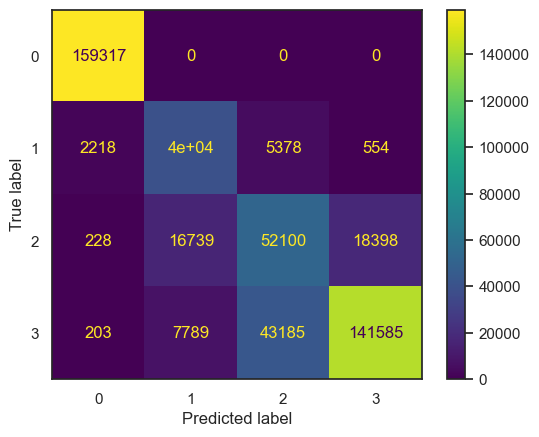

              precision    recall  f1-score   support

           0     0.9836    1.0000    0.9918    159317
           1     0.6176    0.8294    0.7080     47759
           2     0.5176    0.5957    0.5539     87465
           3     0.8819    0.7345    0.8015    192762

    accuracy                         0.8057    487303
   macro avg     0.7502    0.7899    0.7638    487303
weighted avg     0.8239    0.8057    0.8101    487303

Class PR AUC: [[0.9999924040176762, 0.8552988047612452, 0.5653236294064389, 0.920381924252643], [0.9999860742848039, 0.8407996338065276, 0.5828363511094832, 0.9157287520412931], [0.9999868337237292, 0.7938148390843078, 0.5406223515123678, 0.9134142585545458]]
Mac PR AUC: ([0.8352491906095008, 0.8348377028105269, 0.8119595707187376])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=19, hours=90, modus="m")
    results[age] = (X_data, Y_data)

for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 19, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/Ablation_Class1_90min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## 1 hour

Processing age group 0...


2026-03-04 04:06:32.238582: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 04:06:32.238636: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8520, 13, 1)
Total subjects: 247
Shape of first subject data: (8520,)
Alpha weights: [0.56898123 1.9168099  1.0414314  0.4727775 ]


2026-03-04 04:11:07.544085: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/14088 [..............................] - ETA: 56:04

2026-03-04 04:51:16.561995: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14088/14088 [==============================] - 32s 2ms/step


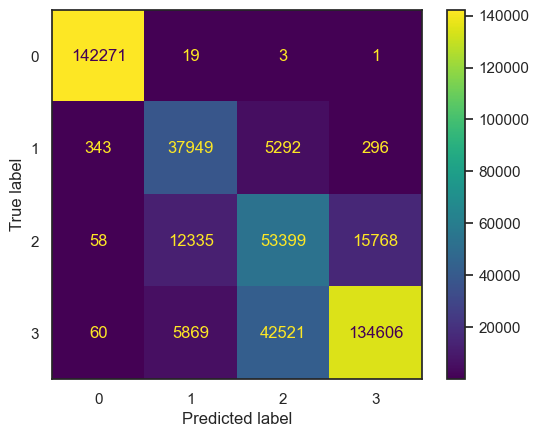

              precision    recall  f1-score   support

           0     0.9968    0.9998    0.9983    142294
           1     0.6756    0.8648    0.7586     43880
           2     0.5276    0.6547    0.5843     81560
           3     0.8934    0.7353    0.8067    183056

    accuracy                         0.8168    450790
   macro avg     0.7733    0.8137    0.7870    450790
weighted avg     0.8386    0.8168    0.8223    450790

Class PR AUC: [[0.9999884001255801, 0.8534607887003042, 0.5659842850976963, 0.9190056879786545]]
Mac PR AUC: ([0.8346097904755587])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8520, 13, 1)
Total subjects: 247
Shape of first subject data: (8520,)
Alpha weights: [0.5909038  1.9062846  1.0356541  0.46715763]


2026-03-04 04:52:04.538657: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 05:31:13.504902: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15081/15081 [==============================] - 38s 2ms/step


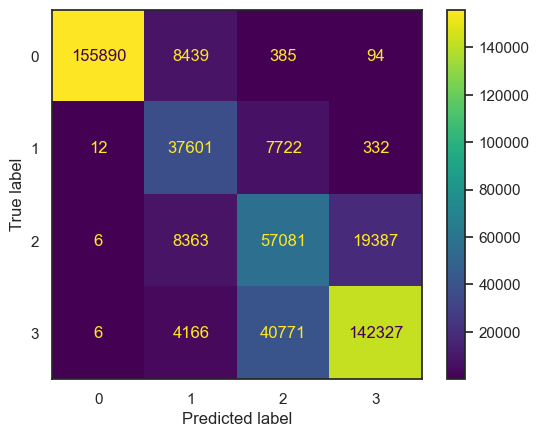

              precision    recall  f1-score   support

           0     0.9998    0.9459    0.9721    164808
           1     0.6420    0.8234    0.7215     45667
           2     0.5387    0.6728    0.5983     84837
           3     0.8778    0.7600    0.8147    187270

    accuracy                         0.8142    482582
   macro avg     0.7646    0.8005    0.7766    482582
weighted avg     0.8376    0.8142    0.8216    482582

Class PR AUC: [[0.9999884001255801, 0.8534607887003042, 0.5659842850976963, 0.9190056879786545], [0.9998629350637005, 0.7739903579993784, 0.594610454866934, 0.914385717118773]]
Mac PR AUC: ([0.8346097904755587, 0.8207123662621966])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8520, 13, 1)
Total subjects: 247
Shape of first subject data: (8520,)
Alpha weights: [0.5758834  1.9194908  1.0372872  0.46733853]


2026-03-04 05:32:06.164546: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 06:09:43.848546: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15359/15359 [==============================] - 37s 2ms/step


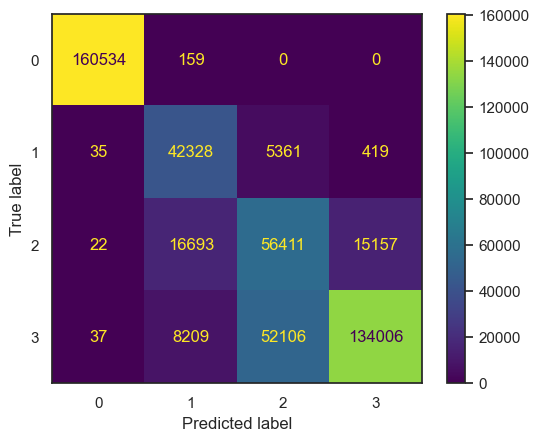

              precision    recall  f1-score   support

           0     0.9994    0.9990    0.9992    160693
           1     0.6281    0.8792    0.7327     48143
           2     0.4954    0.6390    0.5581     88283
           3     0.8959    0.6895    0.7792    194358

    accuracy                         0.8002    491477
   macro avg     0.7547    0.8017    0.7673    491477
weighted avg     0.8316    0.8002    0.8069    491477

Class PR AUC: [[0.9999884001255801, 0.8534607887003042, 0.5659842850976963, 0.9190056879786545], [0.9998629350637005, 0.7739903579993784, 0.594610454866934, 0.914385717118773], [0.9999964167323319, 0.8333447083118309, 0.5300716248125689, 0.9120149535921376]]
Mac PR AUC: ([0.8346097904755587, 0.8207123662621966, 0.8188569258622174])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=13, hours=1, modus="h")
    results[age] = (X_data, Y_data)

for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 13, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/Ablation_Class1_60min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## 2 hours

2026-03-04 06:10:37.035889: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 06:10:37.035928: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 0...
Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8387, 25, 1)
Total subjects: 247
Shape of first subject data: (8387,)
Alpha weights: [0.5688907 1.9168463 1.0419306 0.4723326]


2026-03-04 06:15:20.040977: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/13877 [..............................] - ETA: 57:57

2026-03-04 06:56:27.889650: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


13877/13877 [==============================] - 32s 2ms/step


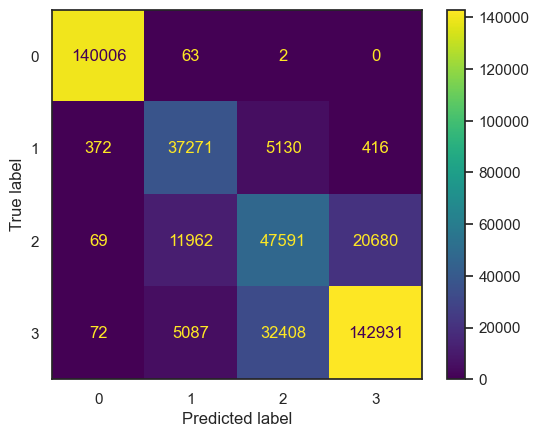

              precision    recall  f1-score   support

           0     0.9963    0.9995    0.9979    140071
           1     0.6853    0.8630    0.7640     43189
           2     0.5590    0.5927    0.5754     80302
           3     0.8714    0.7919    0.8297    180498

    accuracy                         0.8283    444060
   macro avg     0.7780    0.8118    0.7917    444060
weighted avg     0.8362    0.8283    0.8304    444060

Class PR AUC: [[0.9999896387663777, 0.8502653934216181, 0.5742872379293301, 0.9193564262336855]]
Mac PR AUC: ([0.835974674087753])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8387, 25, 1)
Total subjects: 247
Shape of first subject data: (8387,)
Alpha weights: [0.5905242  1.9064493  1.0362664  0.46676016]


2026-03-04 06:57:15.134135: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/14808 [..............................] - ETA: 1:02:55

2026-03-04 07:36:53.555058: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14808/14808 [==============================] - 34s 2ms/step


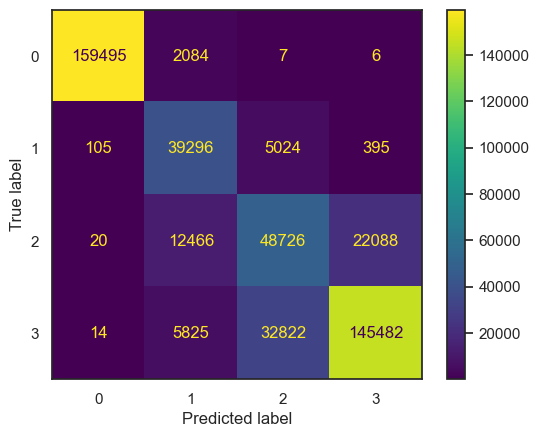

              precision    recall  f1-score   support

           0     0.9991    0.9870    0.9930    161592
           1     0.6585    0.8768    0.7521     44820
           2     0.5628    0.5849    0.5737     83300
           3     0.8661    0.7900    0.8263    184143

    accuracy                         0.8294    473855
   macro avg     0.7716    0.8097    0.7863    473855
weighted avg     0.8385    0.8294    0.8317    473855

Class PR AUC: [[0.9999896387663777, 0.8502653934216181, 0.5742872379293301, 0.9193564262336855], [0.9999199253956568, 0.8309494194635072, 0.5847119740872068, 0.9152814145040128]]
Mac PR AUC: ([0.835974674087753, 0.8327156833625958])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8387, 25, 1)
Total subjects: 247
Shape of first subject data: (8387,)
Alpha weights: [0.5758652 1.9196836 1.0376171 0.4668344]


2026-03-04 07:37:44.593473: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


    1/15098 [..............................] - ETA: 1:03:44

2026-03-04 08:17:05.068736: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15098/15098 [==============================] - 34s 2ms/step


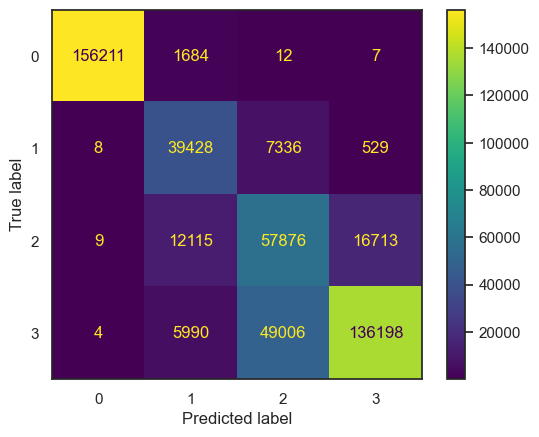

              precision    recall  f1-score   support

           0     0.9999    0.9892    0.9945    157914
           1     0.6658    0.8336    0.7403     47301
           2     0.5067    0.6674    0.5760     86713
           3     0.8876    0.7123    0.7904    191198

    accuracy                         0.8066    483126
   macro avg     0.7650    0.8006    0.7753    483126
weighted avg     0.8342    0.8066    0.8137    483126

Class PR AUC: [[0.9999896387663777, 0.8502653934216181, 0.5742872379293301, 0.9193564262336855], [0.9999199253956568, 0.8309494194635072, 0.5847119740872068, 0.9152814145040128], [0.9999793202803784, 0.8157154659297319, 0.5448681786706774, 0.912958913197667]]
Mac PR AUC: ([0.835974674087753, 0.8327156833625958, 0.8183804695196136])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=25, hours=2, modus="h")
    results[age] = (X_data, Y_data)

for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 25, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/Ablation_Class1_120min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## Class Set 2

2026-03-04 16:29:38.491197: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 16:29:38.491239: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 0...
Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)
Alpha weights: [0.6630905 1.6972148 0.9394924 0.7002021]


2026-03-04 16:34:16.990955: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 17:12:57.795960: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14198/14198 [==============================] - 34s 2ms/step


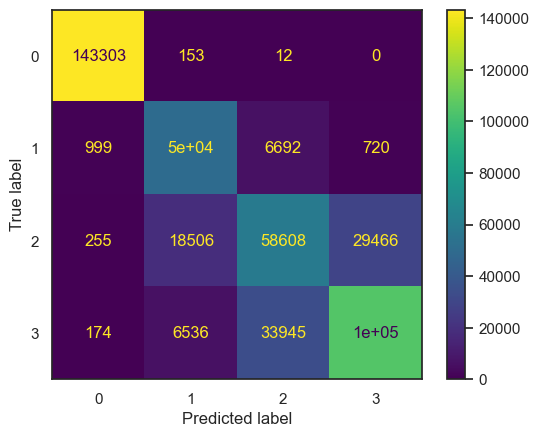

              precision    recall  f1-score   support

           0     0.9901    0.9988    0.9945    143468
           1     0.6648    0.8560    0.7484     58390
           2     0.5905    0.5486    0.5688    106835
           3     0.7767    0.7208    0.7477    145630

    accuracy                         0.7855    454323
   macro avg     0.7555    0.7811    0.7648    454323
weighted avg     0.7859    0.7855    0.7836    454323

Class PR AUC: [[0.999948670687747, 0.8393863230194829, 0.5826137792568409, 0.8262138680943706]]
Mac PR AUC: ([0.8120406602646104])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)
Alpha weights: [0.6885884 1.6877114 0.9328445 0.6908558]


2026-03-04 17:13:47.849248: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 17:51:44.900951: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15223/15223 [==============================] - 37s 2ms/step


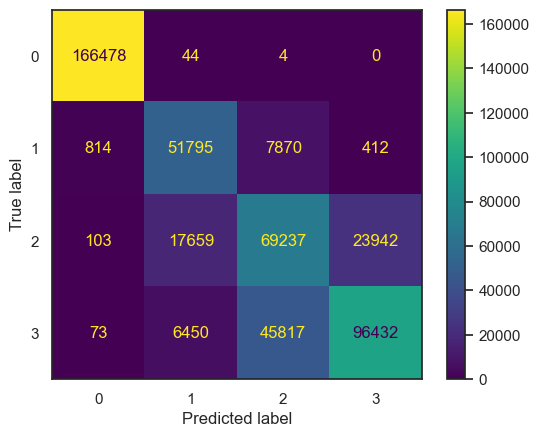

              precision    recall  f1-score   support

           0     0.9941    0.9997    0.9969    166526
           1     0.6820    0.8506    0.7570     60891
           2     0.5632    0.6241    0.5921    110941
           3     0.7984    0.6482    0.7155    148772

    accuracy                         0.7882    487130
   macro avg     0.7594    0.7807    0.7654    487130
weighted avg     0.7972    0.7882    0.7888    487130

Class PR AUC: [[0.999948670687747, 0.8393863230194829, 0.5826137792568409, 0.8262138680943706], [0.9999894500569859, 0.8467736931997908, 0.5769466260791019, 0.8180467169240513]]
Mac PR AUC: ([0.8120406602646104, 0.8104391215649824])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 247
Shape of first subject data: (8586, 7, 1)
Total subjects: 247
Shape of first subject data: (8586,)
Alpha weights: [0.67224544 1.7002205  0.9350612  0.6924729 ]


2026-03-04 17:52:39.603703: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 18:28:30.772562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


15495/15495 [==============================] - 38s 2ms/step


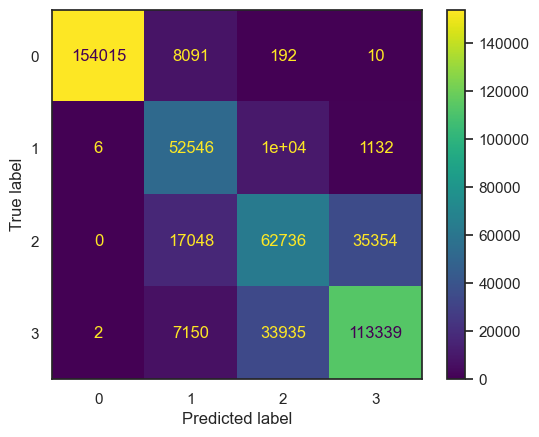

              precision    recall  f1-score   support

           0     0.9999    0.9489    0.9738    162308
           1     0.6194    0.8215    0.7063     63966
           2     0.5855    0.5449    0.5645    115138
           3     0.7564    0.7339    0.7450    154426

    accuracy                         0.7717    495838
   macro avg     0.7403    0.7623    0.7474    495838
weighted avg     0.7788    0.7717    0.7730    495838

Class PR AUC: [[0.999948670687747, 0.8393863230194829, 0.5826137792568409, 0.8262138680943706], [0.9999894500569859, 0.8467736931997908, 0.5769466260791019, 0.8180467169240513], [0.9999843208190323, 0.732359852823564, 0.5835887943288721, 0.8175058337538696]]
Mac PR AUC: ([0.8120406602646104, 0.8104391215649824, 0.7833597004313345])


: 

In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class2", sample_count=7, hours=30, modus="m")
    results[age] = (X_data, Y_data)

for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 7, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/Ablation_Class2_30min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## Metrics

In [33]:
files = ["Ablations/Ablation_Class1_30min.txt", 
         "Ablations/Ablation_Class1_45min.txt", 
         "Ablations/Ablation_Class1_60min.txt",
         "Ablations/Ablation_Class1_90min.txt",
         "Ablations/Ablation_Class1_120min.txt" ]

# general regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}

# helper function to extract numeric arrays
def extract_arrays(block_text):
    """Extracts all bracketed numeric arrays from a text block."""
    arrays = re.findall(r"\[([^\]]+)\]", block_text)
    parsed = [np.fromstring(a.replace(",", " "), sep=" ") for a in arrays]
    return np.array(parsed)

for file in files: 
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all = arrays
        elif metric_name == "Recall":
            recall_all = arrays
        elif metric_name == "Precision":
            precision_all = arrays
        elif metric_name == "PR AUC":
            pr_auc_all = arrays

    # computes summary stats
    def summarize(metric, name):
        if metric.size == 0:
            print(f"\n{name}: No data found.")
            return
        mean_per_class = np.mean(metric, axis=0)
        std_per_class = np.std(metric, axis=0)
        macro_mean = np.mean(mean_per_class)
        macro_std = np.std(mean_per_class)

        print(f"\n{name} Results:")
        print(f"Mean per Class: {np.round(mean_per_class, 4)}")
        print(f"Std per Class:  {np.round(std_per_class, 4)}")
        print(f"Macro Mean: {macro_mean:.4f}, Macro Std: {macro_std:.4f}")
        

    # summarizes all metrics
    summarize(f1_all, "F1 Measure")
    summarize(recall_all, "Recall")
    summarize(precision_all, "Precision")
    summarize(pr_auc_all, "PR AUC")
    print("--------------------")


F1 Measure Results:
Mean per Class: [0.991  0.7339 0.5693 0.7964]
Std per Class:  [0.0087 0.0055 0.0096 0.0129]
Macro Mean: 0.7727, Macro Std: 0.1509

Recall Results:
Mean per Class: [0.986  0.8586 0.6389 0.7239]
Std per Class:  [0.0192 0.0109 0.0437 0.0281]
Macro Mean: 0.8019, Macro Std: 0.1321

Precision Results:
Mean per Class: [0.9964 0.641  0.5154 0.8864]
Std per Class:  [0.0041 0.0101 0.014  0.012 ]
Macro Mean: 0.7598, Macro Std: 0.1909

PR AUC Results:
Mean per Class: [1.     0.8151 0.5466 0.9125]
Std per Class:  [0.     0.0263 0.0036 0.0026]
Macro Mean: 0.8185, Macro Std: 0.1701
--------------------

F1 Measure Results:
Mean per Class: [0.9925 0.7432 0.5774 0.7996]
Std per Class:  [0.0081 0.0104 0.0129 0.0052]
Macro Mean: 0.7782, Macro Std: 0.1483

Recall Results:
Mean per Class: [0.9873 0.8503 0.6536 0.7279]
Std per Class:  [0.0172 0.0194 0.0275 0.0072]
Macro Mean: 0.8048, Macro Std: 0.1267

Precision Results:
Mean per Class: [0.9979 0.6601 0.5175 0.887 ]
Std per Class:  [0.0

In [47]:
files = ["Ablations/Ablation_Class0_30min_default.txt" ,
         "Ablations/Ablation_Class0_30min.txt"]

# general regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}

# helper function to extract numeric arrays
def extract_arrays(block_text):
    """Extracts all bracketed numeric arrays from a text block."""
    arrays = re.findall(r"\[([^\]]+)\]", block_text)
    parsed = [np.fromstring(a.replace(",", " "), sep=" ") for a in arrays]
    return np.array(parsed)

for file in files: 
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all = arrays
        elif metric_name == "Recall":
            recall_all = arrays
        elif metric_name == "Precision":
            precision_all = arrays
        elif metric_name == "PR AUC":
            pr_auc_all = arrays

    # computes summary stats
    def summarize(metric, name):
        if metric.size == 0:
            print(f"\n{name}: No data found.")
            return
        mean_per_class = np.mean(metric, axis=0)
        std_per_class = np.std(metric, axis=0)
        macro_mean = np.mean(mean_per_class)
        macro_std = np.std(mean_per_class)

        print(f"\n{name} Results:")
        print(f"Mean per Class: {np.round(mean_per_class, 4)}")
        print(f"Std per Class:  {np.round(std_per_class, 4)}")
        print(f"Macro Mean: {macro_mean:.4f}, Macro Std: {macro_std:.4f}")
        

    # summarizes all metrics
    summarize(f1_all, "F1 Measure")
    summarize(recall_all, "Recall")
    summarize(precision_all, "Precision")
    summarize(pr_auc_all, "PR AUC")
    print("--------------------")


F1 Measure Results:
Mean per Class: [0.9952 0.7597 0.5405 0.4163 0.7906]
Std per Class:  [0.0028 0.0118 0.0101 0.0201 0.0049]
Macro Mean: 0.7005, Macro Std: 0.2024

Recall Results:
Mean per Class: [0.9998 0.7857 0.545  0.3534 0.8417]
Std per Class:  [0.0001 0.0409 0.0177 0.0292 0.02  ]
Macro Mean: 0.7051, Macro Std: 0.2286

Precision Results:
Mean per Class: [0.9906 0.7372 0.537  0.5088 0.7458]
Std per Class:  [0.0055 0.0159 0.02   0.0018 0.0115]
Macro Mean: 0.7039, Macro Std: 0.1738

PR AUC Results:
Mean per Class: [1.     0.8362 0.5469 0.4589 0.8571]
Std per Class:  [0.     0.0121 0.0139 0.0121 0.0032]
Macro Mean: 0.7398, Macro Std: 0.2034
--------------------

F1 Measure Results:
Mean per Class: [0.9967 0.7486 0.5331 0.4634 0.75  ]
Std per Class:  [0.001  0.013  0.0173 0.016  0.0165]
Macro Mean: 0.6984, Macro Std: 0.1880

Recall Results:
Mean per Class: [0.9978 0.8492 0.6464 0.4622 0.6882]
Std per Class:  [0.0014 0.0085 0.024  0.0402 0.0339]
Macro Mean: 0.7288, Macro Std: 0.1824

P